# Simulación multiagente v2: zonas, escolta y recarga de gasolina

Sobre el modelo de `granja.py` (mismo del notebook anterior) se agregaron tres mejoras:

1. **Auto-asignación de zonas**: cada `Harvester`, al arrancar, reparte las
   columnas del campo entre él y sus hermanos según su posición inicial
   (`autoasignarZona`). Prioriza cosechar dentro de su propia franja y solo
   sale a ayudar en otras cuando ya no le queda nada pendiente ahí — así no
   convergen los tres sobre el mismo parche. La reserva de la celda objetivo
   (`model.reservadas`) sigue siendo compartida entre todos para nunca pisarse.
2. **Tractores que siguen a su harvester**: cuando un `Tractor` está libre
   (sin carga, sin llamada activa) se acerca y se queda cerca del harvester
   que tiene asignado (`seguirHarvester`), en vez de esperar quieto. Así,
   cuando el harvester se llena, el tractor casi siempre ya está cerca.
3. **Carga de gasolina**: silo y gasolinera comparten ubicación (`model.base`).
   Cuando el tanque de cualquier agente baja del umbral (`umbral_gasolina`,
   20% por defecto) y no está a mitad de una entrega, se desvía a recargar
   antes de seguir trabajando.

In [1]:
import agentpy as ap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from IPython.display import HTML

from granja import GranjaModel, PARAMETROS

print("agentpy", ap.__version__)
PARAMETROS

agentpy 0.1.5


{'shape': (40, 40),
 'ancho_camino': 2,
 'pct_obstaculos': 0.02,
 'n_harvesters': 3,
 'n_tractores': 2,
 'tamano_harvester': 2,
 'velocidad_harvester': 1,
 'capacidad_harvester': 25,
 'gasolina_harvester': 1200,
 'consumo_harvester': 1.0,
 'velocidad_tractor': 2,
 'capacidad_tractor': 80,
 'gasolina_tractor': 1500,
 'consumo_tractor': 0.7,
 'tasa_vertido': 8,
 'umbral_gasolina': 0.2,
 'seed': 1,
 'steps': 1200}

## Corrida sin animación — métricas del reto

In [2]:
parametros = dict(PARAMETROS)
parametros['shape'] = (30, 30)
parametros['steps'] = 1500

model = GranjaModel(parametros)
results = model.run()
results.reporters

Completed: 452 steps
Run time: 0:00:00.279558
Simulation finished


,seed,pasos,cosechado_pct,grano_entregado,distancia_total,combustible_usado,giros_totales,recargas_totales
0,1,452,100.0,500,2131,1708.0,322,0


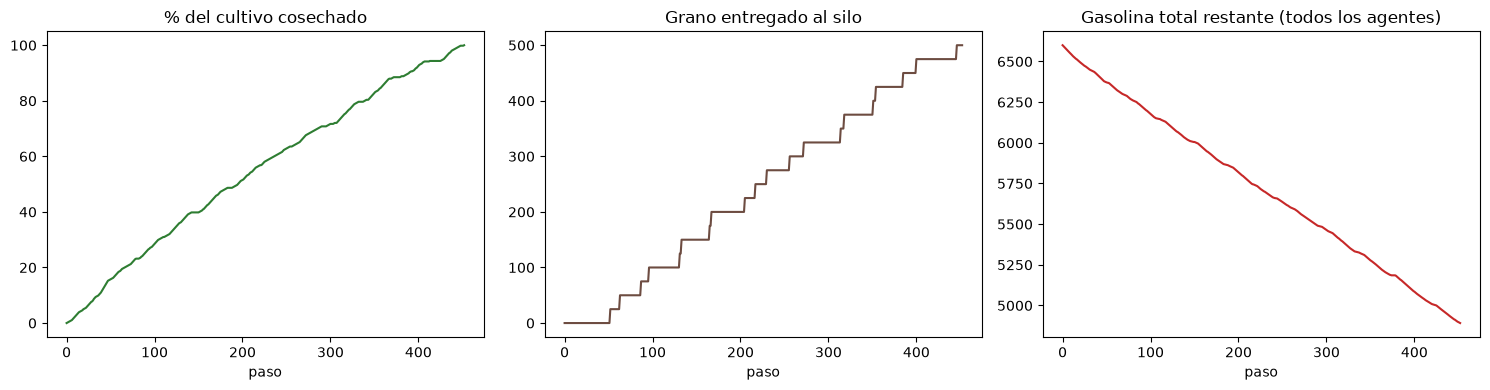

In [3]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
data = results.variables.GranjaModel

data['cosechado_pct'].plot(ax=axs[0], color='#2e7d32')
axs[0].set_title('% del cultivo cosechado')
axs[0].set_xlabel('paso')

data['grano_entregado'].plot(ax=axs[1], color='#6d4c41')
axs[1].set_title('Grano entregado al silo')
axs[1].set_xlabel('paso')

data['gasolina_total'].plot(ax=axs[2], color='#c62828')
axs[2].set_title('Gasolina total restante (todos los agentes)')
axs[2].set_xlabel('paso')

plt.tight_layout()
plt.show()

## Poniendo a prueba la recarga

Con tanques chicos, para forzar varias visitas a la gasolinera dentro de la
misma corrida y confirmar que el ciclo cosechar → entregar → recargar no se
traba.

In [4]:
parametros_gas = dict(PARAMETROS)
parametros_gas['shape'] = (26, 26)
parametros_gas['steps'] = 3000
parametros_gas['gasolina_harvester'] = 150
parametros_gas['gasolina_tractor'] = 150
parametros_gas['umbral_gasolina'] = 0.25

modelo_gas = GranjaModel(parametros_gas)
resultados_gas = modelo_gas.run()
resultados_gas.reporters

Completed: 397 steps
Run time: 0:00:00.130038
Simulation finished


,seed,pasos,cosechado_pct,grano_entregado,distancia_total,combustible_usado,giros_totales,recargas_totales
0,1,397,100.0,350,1606,410.9,278,7


## Animación

Colores del campo: café = camino de tierra, verde = cultivo listo, dorado =
cosechado, gris = obstáculo. Cuadro negro = silo / gasolinera.

Harvesters (triángulo): azul = operando, naranja = esperando tractor, morado
= vertiendo, negro = recargando, rojo oscuro = sin gasolina.

Tractores (círculo): gris = libre, amarillo = escoltando a su harvester,
naranja = en camino a atender una llamada, morado = descargando, azul = yendo
al silo, negro = recargando.

In [5]:
COLOR_TERRENO = mcolors.ListedColormap(
    ['#c2a878', '#7cb342', '#c9b458', '#4a4a4a'])  # camino, listo, cosechado, obstaculo

COLOR_HARVESTER = {
    'operando': '#1565c0',
    'esperando_tractor': '#ef6c00',
    'vertiendo': '#6a1b9a',
    'recargando': '#212121',
    'sin_gasolina': '#b71c1c',
}

COLOR_TRACTOR = {
    'libre': '#9e9e9e',
    'escoltando': '#fdd835',
    'en_camino': '#ef6c00',
    'descargando': '#6a1b9a',
    'al_silo': '#1565c0',
    'recargando': '#212121',
    'sin_gasolina': '#b71c1c',
}


def dibujar_campo(model, ax):
    ax.clear()
    ax.imshow(model.campo.terreno, cmap=COLOR_TERRENO, vmin=0, vmax=3, origin='upper')

    silo = model.silo
    ax.scatter([silo[1]], [silo[0]], marker='s', c='black', s=140, zorder=5)

    if len(model.harvesters):
        hy = [h.ubicacion[0] for h in model.harvesters]
        hx = [h.ubicacion[1] for h in model.harvesters]
        colores = [COLOR_HARVESTER.get(h.estado, 'gray') for h in model.harvesters]
        ax.scatter(hx, hy, marker='^', c=colores, s=160,
                   edgecolors='white', linewidths=1, zorder=6)

    if len(model.tractores):
        ty = [t.ubicacion[0] for t in model.tractores]
        tx = [t.ubicacion[1] for t in model.tractores]
        colores_t = [COLOR_TRACTOR.get(t.estado, 'red') for t in model.tractores]
        ax.scatter(tx, ty, marker='o', c=colores_t, s=120,
                   edgecolors='white', linewidths=1, zorder=6)

    pct = 100 * model.cosechado / model.campo.total_cultivo
    ax.set_title(f"t={model.t}   cosechado={pct:.1f}%   grano entregado={model.entregado}")
    ax.set_xticks([])
    ax.set_yticks([])

In [6]:
parametros_anim = dict(PARAMETROS)
parametros_anim['shape'] = (24, 24)
parametros_anim['steps'] = 500

fig, ax = plt.subplots(figsize=(7, 7))
modelo_anim = GranjaModel(parametros_anim)
animacion = ap.animate(modelo_anim, fig, ax, dibujar_campo)
plt.close(fig)
HTML(animacion.to_jshtml())

### Guardar como GIF numerado

Se guarda en `GIFS/` con un número consecutivo cada vez que se corre esta
celda, sin pisar corridas anteriores.

In [ ]:
import os

carpeta_gifs = 'GIFS'
os.makedirs(carpeta_gifs, exist_ok=True)
existentes = [f for f in os.listdir(carpeta_gifs) if f.startswith('cosecha_') and f.endswith('.gif')]
numeros = [int(f[len('cosecha_'):-len('.gif')]) for f in existentes if f[len('cosecha_'):-len('.gif')].isdigit()]
siguiente = max(numeros, default=0) + 1

ruta_gif = os.path.join(carpeta_gifs, f'cosecha_{siguiente}.gif')
animacion.save(ruta_gif, writer='pillow', fps=15)
print('guardado:', ruta_gif)

guardado: GIFS\cosecha_1.gif
